# Predição de churn

Este notebook apresenta um fluxo de análise de dados e construção de um modelo preditivo para identificar clientes com maior probabilidade de cancelamento (churn), utilizando o dataset Telco Customer Churn ([link](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)).

O projeto contempla as etapas de preparação dos dados, análise exploratória, engenharia de atributos, preparação para Machine Learning, treinamento e avaliação dos modelos.


## 1. Imports

In [212]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
	confusion_matrix, 
	ConfusionMatrixDisplay, 
	roc_curve, 
	roc_auc_score, 
	precision_recall_curve, 
	average_precision_score,
	accuracy_score,
	precision_score,
	recall_score,
	f1_score
)

## 2. Preparação dos dados

Nessa etapa os dados são carregados, inspecionados e preparados para análise.

Também são realizados tratamentos, como correção de tipos de dados, tratamento de valores ausentes e adequação da variável alvo para os modelos de Machine Learning.

In [213]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [215]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [216]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [217]:
# tratando a coluna TotalCharges que estava com obj, mas é numerica
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

df['TotalCharges'].isnull().sum()

np.int64(11)

In [218]:
df.fillna({'TotalCharges':0}, inplace=True)

In [219]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [220]:
# transf a coluna Churn em 1 ou 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [221]:
# removendo o identificador do cliente, pois ele não possui valor preditivo - não irei usar
df.drop('customerID', axis=1, inplace=True)

In [222]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Análise Exploratória dos Dados (EDA)

O objetivo dessa etapa é compreender o comportamento dos clientes, identificar padrões relacionados ao churn e levantar hipóteses que possam orientar a construção do modelo preditivo.

In [223]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100

churn_counts

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

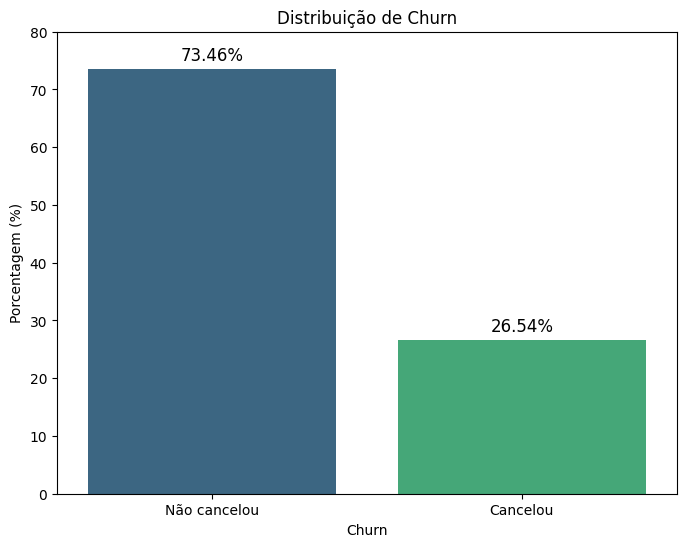

In [224]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=churn_counts.index.map({0: 'Não cancelou', 1: 'Cancelou'}), y=churn_counts.values, hue=churn_counts.index.map({0: 'Não cancelou', 1: 'Cancelou'}), palette='viridis')
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Porcentagem (%)')
for p in ax.patches:
  ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
    ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
    textcoords='offset points')
plt.ylim(0, 80)
plt.show()

Cerca de 26,5% dos clientes cancelaram. Embora não seja um desbalanceamento severo, existe uma diferença relevante entre as classes, justificando a análise de métricas como Recall e F1-score além da Accuracy.

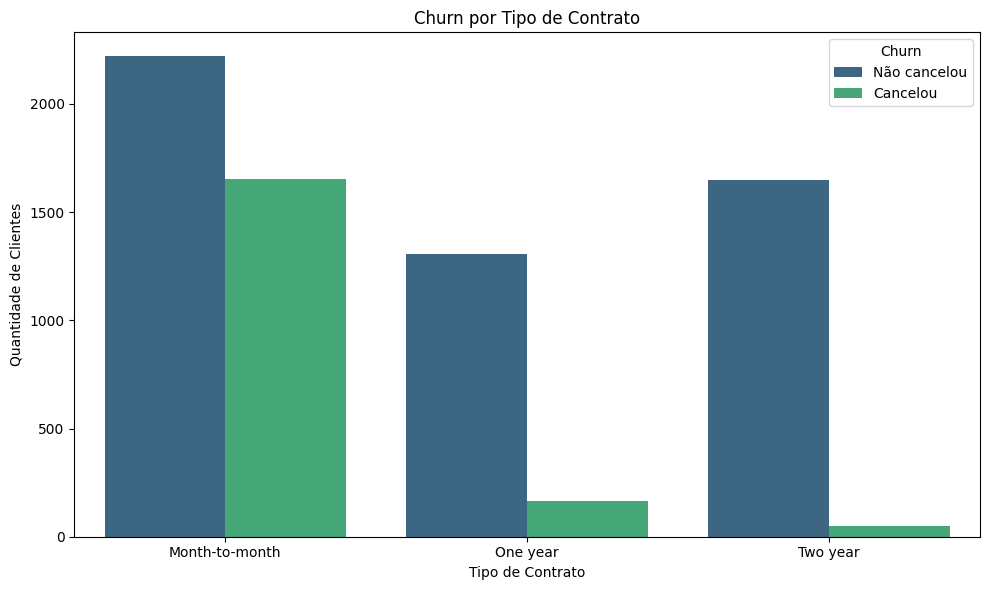

In [225]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn', labels=['Não cancelou', 'Cancelou'])
plt.tight_layout()
plt.show()

Observa-se que clientes com contratos mensais apresentam uma frequência significativamente maior de churn em comparação aos clientes com contratos anuais.

Esse comportamento sugere que contratos de maior duração contribuem para a retenção dos clientes.

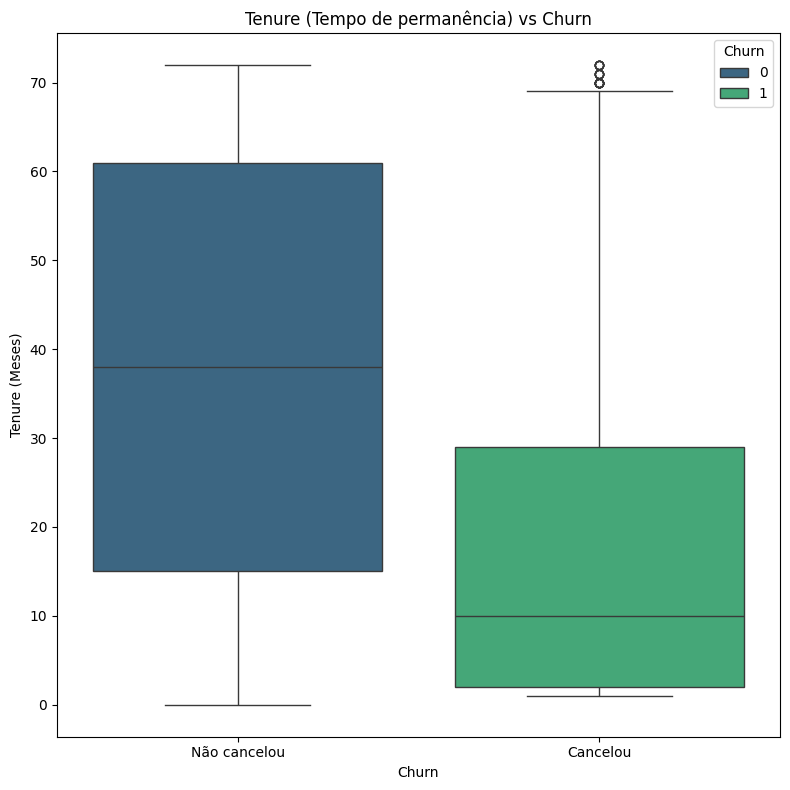

In [226]:
plt.figure(figsize=(8, 8))
sns.boxplot(x='Churn', y='tenure', data=df, palette='viridis', hue='Churn')
plt.title('Tenure (Tempo de permanência) vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Meses)')
plt.xticks([0, 1], ['Não cancelou', 'Cancelou'])
plt.tight_layout()
plt.show()


A mediana de tenure para clientes que cancelam é bem menor (~10 meses) comparada aos que ficam (~38 meses). 
Clientes que cancelaram apresentam uma mediana de tempo de permanência significativamente menor.
Esse comportamento indica que o risco de churn é maior durante os primeiros meses de relacionamento com a empresa.

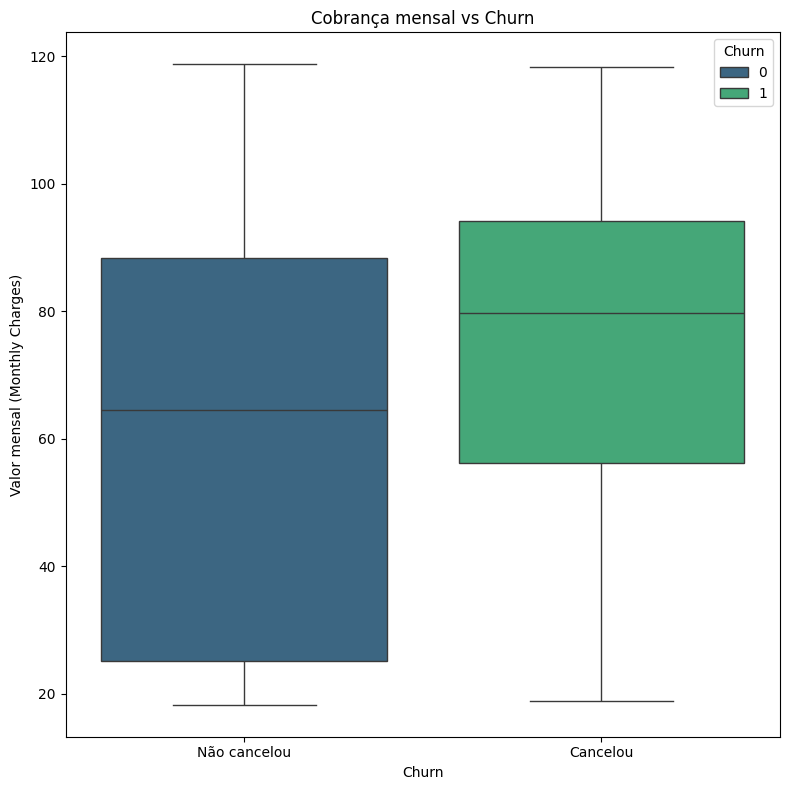

In [227]:
plt.figure(figsize=(8, 8))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis', hue='Churn')
plt.title('Cobrança mensal vs Churn')
plt.xlabel('Churn')
plt.ylabel('Valor mensal (Monthly Charges)')
plt.xticks([0, 1], ['Não cancelou', 'Cancelou'])
plt.tight_layout()
plt.show()

A mediana do valor mensal é mais alta entre os que cancelam, indicando que preços mais elevados podem influenciar na decisão de cancelamento.

In [228]:
# df.columns

## 4. Feature Engineering

Nesta etapa são criadas novas features a partir dos dados existentes.

O objetivo é representar melhor o comportamento dos clientes e fornecer informações mais relevantes para os modelos.

### Cliente recente

Hipótese:

- Clientes com pouco tempo de relacionamento tendem a cancelar com maior frequência.

Foi criada uma variável binária indicando se o cliente possui até 12 meses de permanência.

In [229]:
df['new_customer'] = (df['tenure'] <= 12).astype(int)
df[['tenure', 'new_customer']].head()

,tenure,new_customer
0,1,1
1,34,0
2,2,1
3,45,0
4,2,1


### Quantidade de serviços contratados

Hipótese:

- Clientes que utilizam mais serviços possuem maior vínculo com a empresa e, consequentemente, menor propensão ao churn.

In [230]:
service_columns = [
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies'
]

In [231]:
df['num_services'] = (
  df[service_columns]
  .apply(lambda row: (row == 'Yes').sum(), axis=1)
)

In [232]:
df[['num_services', 'Churn']].head()

,num_services,Churn
0,1,0
1,2,0
2,2,1
3,3,0
4,0,1


### Gasto médio mensal

Hipótese:

- O valor médio pago ao longo do relacionamento pode representar diferentes perfis de clientes e auxiliar na identificação do risco de cancelamento.

In [233]:
df['avg_monthly_spend'] = (
  df['TotalCharges'] /
  df['tenure'].replace(0, pd.NA)
)

In [234]:
df['avg_monthly_spend'].fillna(
  df['MonthlyCharges'],
  inplace=True
)

/tmp/ipykernel_110492/2086531929.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_monthly_spend'].fillna(
/tmp/ipykernel_110492/2086531929.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['avg_monthly_spend'].fillna(


In [235]:
df[['TotalCharges', 'tenure', 'avg_monthly_spend']].head()

,TotalCharges,tenure,avg_monthly_spend
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


### Cliente com cobrança alta

Hipótese:

- Clientes que pagam valores acima da média podem apresentar maior sensibilidade ao preço e maior probabilidade de cancelamento.

In [236]:
monthly_average = df['MonthlyCharges'].mean()

df['high_monthly_charge'] = (
  df['MonthlyCharges'] > monthly_average
).astype(int)

df[['MonthlyCharges', 'high_monthly_charge']].head()

,MonthlyCharges,high_monthly_charge
0,29.85,0
1,56.95,0
2,53.85,0
3,42.30,0
4,70.70,1


In [237]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,new_customer,num_services,avg_monthly_spend,high_monthly_charge
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,1,29.850000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,0,2,55.573529,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,2,54.075000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,3,40.905556,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,0,75.825000,1


### Avaliando as novas variáveis

Após a criação das novas variáveis, é importante verificar se elas apresentam relação com a variável alvo.

O intuito é identificar atributos potencialmente relevantes para os modelos preditivos.

In [238]:
df.groupby('new_customer')['Churn'].mean()

new_customer
0    0.171299
1    0.474382
Name: Churn, dtype: float64

In [239]:
df.groupby('num_services')['Churn'].mean()

num_services
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64

In [240]:
df.groupby('high_monthly_charge')['Churn'].mean()

high_monthly_charge
0    0.164744
1    0.345399
Name: Churn, dtype: float64

A análise exploratória e a engenharia de atributos indicaram alguns padrões:

- Clientes com contratos mensais apresentam maior probabilidade de churn.
- Clientes com menor tempo de relacionamento possuem maior risco de cancelamento.
- Valores mensais elevados parecem estar associados a maiores taxas de churn.
- Clientes com maior quantidade de serviços contratados apresentam comportamento diferente de churn, sugerindo que o nível de relacionamento com a empresa pode influenciar a retenção.

## 5. Pré-processamento dos dados

Nesta etapa será criado um pipeline de pré-processamento responsável por aplicar automaticamente as transformações necessárias em cada tipo de variável.

- As variáveis numéricas serão padronizadas utilizando o StandardScaler.
- As variáveis categóricas serão transformadas utilizando One-Hot Encoding.

Esse processo será integrado ao Pipeline do Scikit-Learn, evitando vazamento de dados durante a validação cruzada.

In [241]:
numeric_features = [
  "SeniorCitizen",
  "tenure",
  "MonthlyCharges",
  "TotalCharges",
  "new_customer",
  "num_services",
  "avg_monthly_spend",
  "high_monthly_charge"
]

In [242]:
categorical_features = [
  "gender",
  "Partner",
  "Dependents",
  "PhoneService",
  "MultipleLines",
  "InternetService",
  "OnlineSecurity",
  "OnlineBackup",
  "DeviceProtection",
  "TechSupport",
  "StreamingTV",
  "StreamingMovies",
  "Contract",
  "PaperlessBilling",
  "PaymentMethod"
]

In [243]:
preprocessor = ColumnTransformer(
  transformers=[
  	(
      "num",
      StandardScaler(),
      numeric_features
    ),
    (
      "cat",
      OneHotEncoder(handle_unknown="ignore"),
      categorical_features
    )
  ]
)

In [244]:
pipeline = Pipeline(
  steps=[
    ("preprocessor", preprocessor),
    (
      "classifier",
      LogisticRegression(
        max_iter=3000,
        random_state=42
      )
    )
  ]
)

In [245]:
# separando o treino e teste
X = df.drop('Churn', axis=1)
y = df['Churn']

In [246]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,new_customer,num_services,avg_monthly_spend,high_monthly_charge
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,1,1,29.850000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,2,55.573529,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,54.075000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,40.905556,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,75.825000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,One year,Yes,Mailed check,84.80,1990.50,0,5,82.937500,1
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,4,102.262500,1
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,1,1,31.495455,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0,76.650000,1


In [247]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [248]:
print(X.shape)
print(y.shape)

(7043, 23)
(7043,)


O uso do Pipeline garante que todas as transformações sejam aplicadas corretamente dentro de cada fold da validação cruzada, evitando data leakage e tornando o fluxo reproduzível.

## 6. Estratégia de validação

Para avaliar a capacidade de generalização dos modelos será utilizado o K-fold estratificado, com k = 5.

In [249]:
kfold = StratifiedKFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

## 7. Baseline

O primeiro modelo desenvolvido será uma Regressão Logística. Esse modelo é geralmente utilizado como baseline em problemas de classificação por ser simples, interpretável e servir como referência para comparar modelos mais complexos.

Métricas utilizadas:

- Accuracy: percentual de previsões corretas.
- Precision: entre todos os clientes previstos como churn, quantos realmente cancelaram.
- Recall: entre todos os clientes que realmente cancelaram, quantos foram identificados pelo modelo.
- F1-score: média harmônica entre Precision e Recall, sendo utilizada como principal métrica devido ao desbalanceamento das classes.

In [250]:
scoring = ["accuracy", "precision", "recall", "f1"]

In [251]:
cv_results = cross_validate(
  estimator=pipeline,
  X=X,
  y=y,
  cv=kfold,
  scoring=scoring
)

In [252]:
results = pd.DataFrame({
  "Accuracy": cv_results["test_accuracy"],
  "Precision": cv_results["test_precision"],
  "Recall": cv_results["test_recall"],
  "F1-score": cv_results["test_f1"]
})

results

,Accuracy,Precision,Recall,F1-score
0,0.810504,0.675410,0.550802,0.606775
1,0.803407,0.653968,0.550802,0.597968
2,0.817601,0.696970,0.553476,0.616990
3,0.795455,0.644068,0.509383,0.568862
4,0.798295,0.653061,0.513369,0.574850


In [253]:
summary = pd.DataFrame({
  "Média": results.mean(),
  "Desvio padrão": results.std()
})

summary

,Média,Desvio padrão
Accuracy,0.805052,0.009051
Precision,0.664695,0.021403
Recall,0.535567,0.022154
F1-score,0.593089,0.020627


O baseline apresentou desempenho consistente durante as cinco divisões da validação cruzada.

O baixo desvio padrão indica estabilidade entre os folds, sugerindo boa capacidade de generalização.

### Interpretação dos resultados

A validação cruzada fornece uma estimativa mais robusta do desempenho do modelo, por considerar cinco divisões diferentes do conjunto de dados.

As métricas médias obtidas pela Regressão Logística serão utilizadas como baseline para comparação com modelos alternativos, como árvores de decisão, Random Forest, KNN e SVM.

Como o conjunto de dados apresenta desbalanceamento entre as classes, a métrica de F1-score será utilizada como principal indicador de desempenho, pois equilibra precisão e recall.

## 8. Comparação entre modelos

Nesta etapa foram avaliados diferentes algoritmos de classificação utilizando validação cruzada estratificada com cinco folds.

A mesma estratégia de avaliação foi aplicada a todos os modelos.

As métricas utilizadas foram:

- Accuracy: proporção de previsões corretas.
- Precision: capacidade de evitar falsos positivos.
- Recall: capacidade de identificar clientes que realmente cancelaram.
- F1-score: média harmônica entre Precision e Recall, utilizada como principal critério de comparação devido à diferença entre as classes.

Embora o F1-score seja utilizado como métrica principal, a escolha do modelo também considera o contexto do problema:

- Recall elevado reduz a quantidade de clientes em risco que deixam de ser identificados.
- Precision elevada reduz custos de ações de retenção realizadas para clientes que não cancelariam.

In [254]:
models = {
  "Logistic Regression": LogisticRegression(
    max_iter=5000,
    random_state=42
  ),

  "Logistic Regression Balanced": LogisticRegression(
    max_iter=5000,
    random_state=42,
    class_weight="balanced"
),

    "Decision Tree": DecisionTreeClassifier(
    random_state=42
  ),

  "Random Forest": RandomForestClassifier(
    random_state=42
  ),

  "KNN": KNeighborsClassifier(),

  "SVM": SVC(
    probability=True,
    random_state=42
  )
}

In [280]:
model_results = []

for name, model in models.items():

  pipeline_model = Pipeline(
    steps=[
      ("preprocessor", preprocessor),
      ("classifier", model)
    ]
  )

  cv_results = cross_validate(
    estimator=pipeline_model,
    X=X,
    y=y,
    cv=kfold,
    scoring=scoring
  )

  model_results.append({
    "Modelo": name,
    "Accuracy": cv_results["test_accuracy"].mean(),
    "Precision": cv_results["test_precision"].mean(),
    "Recall": cv_results["test_recall"].mean(),
    "F1-score": cv_results["test_f1"].mean(),
		"F1_std": cv_results["test_f1"].std()
  })

In [281]:
model_comparison = pd.DataFrame(model_results)

In [282]:
model_comparison_sorted = model_comparison.sort_values(
  by="F1-score",
  ascending=False
)

model_comparison_sorted

,Modelo,Accuracy,Precision,Recall,F1-score,F1_std
1,Logistic Regression Balanced,0.746839,0.514759,0.801480,0.626837,0.011452
0,Logistic Regression,0.805052,0.664695,0.535567,0.593089,0.018450
3,Random Forest,0.792556,0.640807,0.494889,0.558233,0.031609
5,SVM,0.797243,0.669392,0.466002,0.549414,0.028631
4,KNN,0.764587,0.560898,0.520585,0.539951,0.015952
2,Decision Tree,0.724407,0.481587,0.498655,0.489776,0.010696


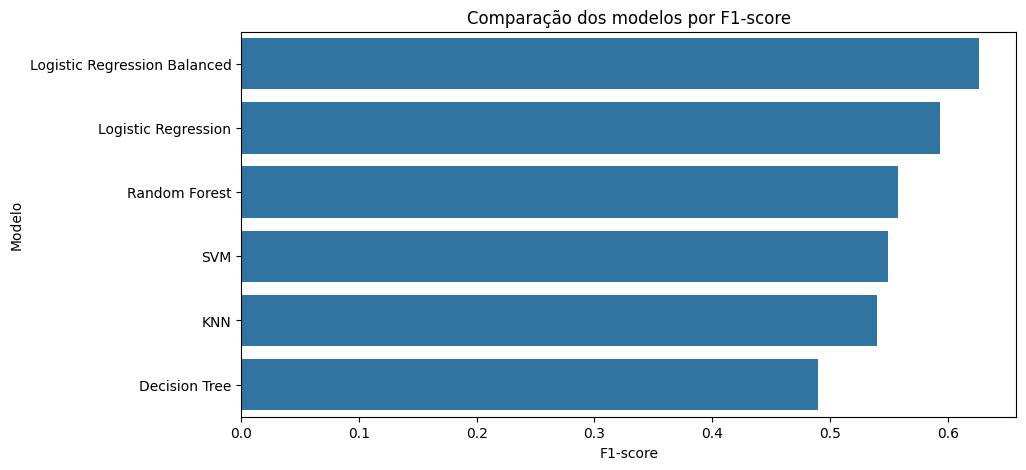

In [258]:
plt.figure(figsize=(10,5))

sns.barplot(
  data=model_comparison_sorted,
  x="F1-score",
  y="Modelo"
)

plt.title("Comparação dos modelos por F1-score")
plt.show()

### Análise dos modelos avaliados

A comparação entre os algoritmos foi realizada utilizando validação cruzada estratificada com cinco folds.

A comparação mostrou que a Regressão Logística Balanceada apresentou o maior F1-score médio entre os modelos avaliados.

Além disso, o modelo apresentou maior Recall em relação à versão tradicional, indicando maior capacidade de identificar clientes propensos ao cancelamento.

Esse comportamento é relevante para problemas de churn, pois reduzir falsos negativos permite identificar uma maior quantidade de clientes que apresentam risco de cancelamento e direcionar ações preventivas de retenção.

Por esse motivo, a Regressão Logística Balanceada foi selecionada para a etapa seguinte de otimização dos hiperparâmetros utilizando GridSearch.

## 9. Otimização de hiperparâmetros

A otimização dos hiperparâmetros foi realizada utilizando o GridSearchCV.

Foram avaliadas diferentes combinações dos parâmetros da Regressão Logística Balanceada, utilizando o F1-score médio obtido na validação cruzada estratificada como critério de seleção.

O objetivo dessa etapa é encontrar uma configuração que maximize o equilíbrio entre precisão e capacidade de identificação dos clientes que apresentam maior risco de churn.

In [259]:
balanced_pipeline = Pipeline(
  steps=[
    ("preprocessor", preprocessor),
    (
      "classifier",
      LogisticRegression(
        max_iter=5000,
        random_state=42,
				class_weight="balanced"
      )
    )
  ]
)

In [260]:
param_grid = {
  "classifier__C": [0.01, 0.1, 1, 10, 100],
  "classifier__solver": ["lbfgs", "liblinear"],
  "classifier__penalty": ["l2"]
}

In [261]:
grid_search = GridSearchCV(
  estimator=balanced_pipeline,
  param_grid=param_grid,
  scoring="f1",
  cv=kfold,
  n_jobs=-1
)

In [262]:
grid_search.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'new_customer',
                                                                          'num_services',
                                                                          'avg_monthly_spend',
                                                                          'high_monthly_charge']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         [...
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [263]:
print(grid_search.best_score_)

0.6293126262541457


In [264]:
best_model_summary = pd.DataFrame({
  "Parâmetro": grid_search.best_params_.keys(),
  "Valor escolhido": grid_search.best_params_.values()
})

best_model_summary

,Parâmetro,Valor escolhido
0,classifier__C,0.1
1,classifier__penalty,l2
2,classifier__solver,liblinear


O parâmetro C controla o nível de regularização da Regressão Logística.

- Valores menores aplicam maior regularização, reduzindo o risco de overfitting.
- Valores maiores permitem um modelo mais flexível.

## 10. Avaliação final

In [265]:
best_model = grid_search.best_estimator_

In [266]:
final_results = cross_validate(
  estimator=best_model,
  X=X,
  y=y,
  cv=kfold,
  scoring=scoring
)

In [267]:
final_metrics = pd.DataFrame({
  "Accuracy": final_results["test_accuracy"],
  "Precision": final_results["test_precision"],
  "Recall": final_results["test_recall"],
  "F1-score": final_results["test_f1"]
})

final_metrics

,Accuracy,Precision,Recall,F1-score
0,0.758694,0.529514,0.815508,0.642105
1,0.747339,0.515050,0.823529,0.633745
2,0.755855,0.526408,0.799465,0.634820
3,0.737926,0.503521,0.766756,0.607864
4,0.749290,0.518261,0.796791,0.628030


In [283]:
final_summary = pd.DataFrame({
  "Média": final_metrics.mean(),
  "Desvio padrão": final_metrics.std()
})

final_summary.round(3)

,Média,Desvio padrão
Accuracy,0.750,0.008
Precision,0.519,0.010
Recall,0.800,0.022
F1-score,0.629,0.013


### Matriz de confusão

In [269]:
y_pred_cv = cross_val_predict(
  best_model,
  X,
  y,
  cv=kfold,
  method="predict"
)

cm = confusion_matrix(
  y,
  y_pred_cv
)

cm

array([[3785, 1389],
       [ 373, 1496]])

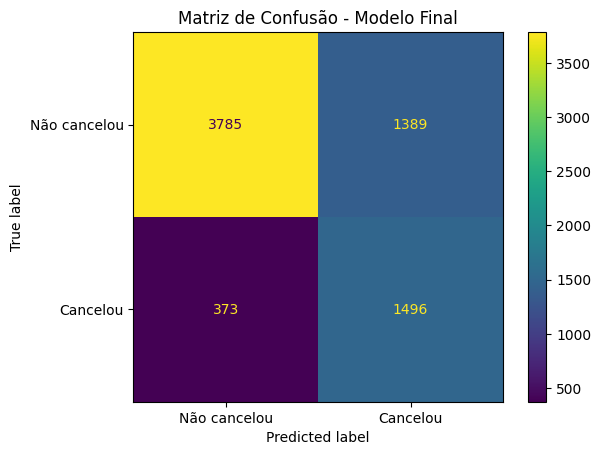

In [270]:
disp = ConfusionMatrixDisplay(
  confusion_matrix=cm,
  display_labels=['Não cancelou', 'Cancelou']
)

disp.plot()

plt.title('Matriz de Confusão - Modelo Final')
plt.show()

### ROC-AUC

In [271]:
y_probability_cv = cross_val_predict(
  best_model,
  X,
  y,
  cv=kfold,
  method="predict_proba"
)[:,1]

In [272]:
fpr, tpr, roc_thresholds = roc_curve(
  y,
  y_probability_cv
)

auc = roc_auc_score(
  y,
  y_probability_cv
)

print(f"AUC: {auc:.3f}")

AUC: 0.845


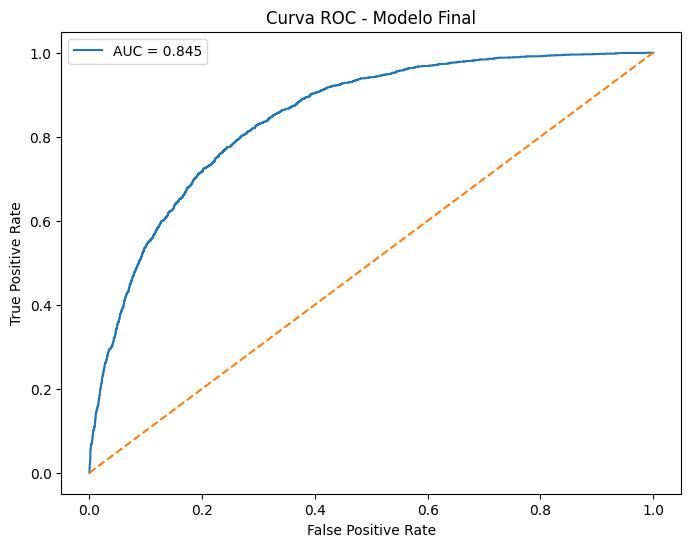

In [273]:
plt.figure(figsize=(8,6))

plt.plot(
  fpr,
  tpr,
  label=f'AUC = {auc:.3f}'
)

plt.plot(
  [0,1],
  [0,1],
  linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Curva ROC - Modelo Final')

plt.legend()

plt.show()

### Curva Precision-Recall

In [274]:
precision, recall, pr_thresholds = precision_recall_curve(
  y,
  y_probability_cv
)

ap = average_precision_score(
  y,
  y_probability_cv
)

print(f"Average Precision: {ap:.3f}")

Average Precision: 0.654


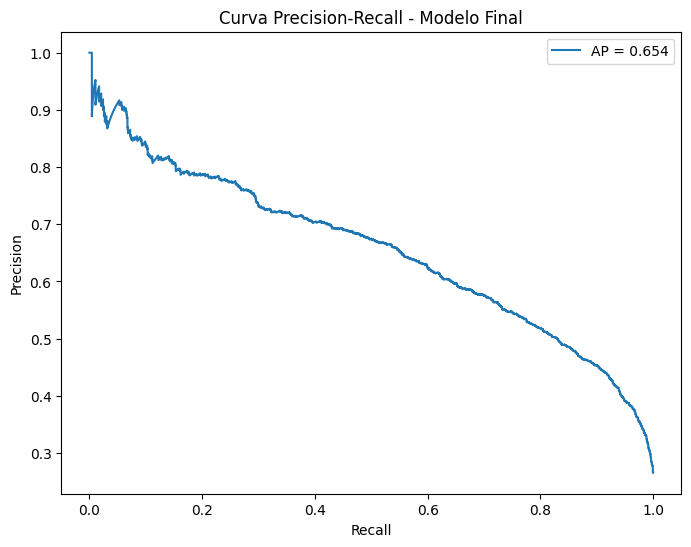

In [275]:
plt.figure(figsize=(8,6))

plt.plot(
  recall,
  precision,
  label=f'AP = {ap:.3f}'
)

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.title('Curva Precision-Recall - Modelo Final')

plt.legend()

plt.show()

A curva Precision-Recall apresentou Average Precision de 0,654, indicando que o modelo possui capacidade moderada de priorizar clientes com maior probabilidade de cancelamento.

Observa-se que existe um trade-off entre Precision e Recall: ao aumentar a capacidade de identificação de clientes em risco, ocorre uma redução na precisão das previsões.

Como o objetivo do problema é identificar clientes com possibilidade de churn para ações preventivas de retenção, o modelo foi avaliado priorizando o Recall, reduzindo a quantidade de clientes perdidos que não seriam identificados pelo algoritmo.

### Interpretação das variáveis

In [276]:
feature_names = (
  best_model.named_steps["preprocessor"]
  .get_feature_names_out()
)

coefficients = best_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
  "Feature": feature_names,
  "Coeficiente": coefficients
})

feature_importance["Impacto"] = (
  feature_importance["Coeficiente"]
  .apply(lambda x: "Aumenta churn" if x > 0 else "Reduz churn")
)

feature_importance.sort_values(
  by="Coeficiente",
  ascending=False
).head(15)

,Feature,Coeficiente,Impacto
40,cat__Contract_Month-to-month,0.655716,Aumenta churn
20,cat__InternetService_Fiber optic,0.364379,Aumenta churn
4,num__new_customer,0.267840,Aumenta churn
47,cat__PaymentMethod_Electronic check,0.233834,Aumenta churn
2,num__MonthlyCharges,0.221429,Aumenta churn
3,num__TotalCharges,0.210619,Aumenta churn
22,cat__OnlineSecurity_No,0.176780,Aumenta churn
31,cat__TechSupport_No,0.154175,Aumenta churn
6,num__avg_monthly_spend,0.111383,Aumenta churn
39,cat__StreamingMovies_Yes,0.088586,Aumenta churn


In [277]:
feature_importance.sort_values(
  by="Coeficiente",
  ascending=True
).head(15)

,Feature,Coeficiente,Impacto
42,cat__Contract_Two year,-0.773108,Reduz churn
1,num__tenure,-0.729412,Reduz churn
19,cat__InternetService_DSL,-0.391009,Reduz churn
43,cat__PaperlessBilling_No,-0.229157,Reduz churn
16,cat__MultipleLines_No,-0.220382,Reduz churn
15,cat__PhoneService_Yes,-0.220365,Reduz churn
24,cat__OnlineSecurity_Yes,-0.203409,Reduz churn
33,cat__TechSupport_Yes,-0.180805,Reduz churn
7,num__high_monthly_charge,-0.160257,Reduz churn
48,cat__PaymentMethod_Mailed check,-0.151298,Reduz churn


### Interpretação dos coeficientes do modelo

A análise dos coeficientes da Regressão Logística permitiu identificar os principais fatores associados ao cancelamento dos clientes.

Entre os fatores associados a maior probabilidade estimada de churn pelo modelo, destacam-se:
- contratos mensais
- clientes recentes
- valores elevados de cobrança mensal
- ausência de serviços adicionais, como suporte técnico e segurança online.

Por outro lado, contratos de maior duração, especialmente contratos de dois anos, e maior tempo de relacionamento com a empresa apresentaram associação negativa com churn, indicando maior retenção dos clientes.

Os resultados encontrados estão alinhados aos padrões observados durante a análise exploratória, reforçando a importância de estratégias de fidelização para clientes nos primeiros meses de relacionamento e para clientes com contratos de menor duração.

### Análise do limiar de decisão (Threshold)

In [278]:
thresholds = [0.3, 0.4, 0.5, 0.6]

threshold_results = []

y_probability = y_probability_cv

for threshold in thresholds:

  y_threshold = (y_probability >= threshold).astype(int)

  threshold_results.append({
    "Threshold": threshold,
    "Accuracy": accuracy_score(y, y_threshold),
    "Precision": precision_score(y, y_threshold),
    "Recall": recall_score(y, y_threshold),
    "F1-score": f1_score(y, y_threshold)
  })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.647735,0.425037,0.928304,0.583095
1,0.4,0.706517,0.471204,0.866774,0.610514
2,0.5,0.749823,0.518544,0.800428,0.629365
3,0.6,0.780633,0.569231,0.712681,0.632929


A análise dos thresholds mostrou que valores maiores reduzem o Recall, porém aumentam a Precision. O threshold de 0.6 apresentou uma pequena melhora no F1-score em relação ao threshold padrão de 0.5. Entretanto, a diferença foi mínima, indicando que ambos apresentam desempenho semelhante. Como o objetivo do problema é identificar clientes com risco de churn, thresholds menores podem ser considerados caso a estratégia priorize maior Recall.

In [284]:
model_package = {
  "model": best_model,
  "threshold": 0.5,
	"description": "Threshold padrão escolhido após análise do equilíbrio entre precision e recall"
}

joblib.dump(
  model_package,
  '../models/churn_model.pkl'
)

['../models/churn_model.pkl']

## 11. Conclusão

Entre os algoritmos avaliados, a Regressão Logística Balanceada apresentou o melhor desempenho segundo o F1-score, sendo selecionada como modelo final devido ao equilíbrio entre precisão e capacidade de identificação dos clientes em risco.

Após a otimização dos hiperparâmetros utilizando GridSearch, o modelo apresentou aproximadamente:

- Accuracy: 75%
- Precision: 52%
- Recall: 80%
- F1-score: 63%

O Recall elevado indica que o modelo consegue identificar uma parcela significativa dos clientes que realmente cancelariam, característica importante em estratégias de retenção.

A avaliação complementar apresentou AUC próxima de 0.85, indicando boa capacidade discriminativa entre clientes propensos e não propensos ao churn.

A análise de threshold demonstrou que a escolha do ponto de corte influencia diretamente o equilíbrio entre Precision e Recall. Dessa forma, a decisão final deve considerar os custos associados às ações de retenção e ao risco de perda de clientes.